In [2]:
import logging
import os

from dotenv import load_dotenv
from matplotlib.ticker import FuncFormatter
from matplotlib import pyplot as plt
from pathlib import Path
from typing import Tuple

import numpy as np
import polars as pl

# Env
pl.Config.set_tbl_rows(10)
load_dotenv("../.env")
INSTALL_PATH = os.environ["INSTALL_PATH"]
AF_URL = os.environ["API_URL_ALPHAFOLD_STRUCTPRED"]

# Logging
logging.basicConfig(
    level=logging.INFO,
    format="%(levelname)s:%(name)s:%(message)s"
)
logger = logging.getLogger(__name__)

### Steps

1. Apply preliminary filtering criteria
2. Apply PyMOL alignment
3. Lookup how SMARCA4, KPNA2 fare

In [36]:
# ────────────────────────────────────────────────────────────
#      Args
# ────────────────────────────────────────────────────────────

VAR_NAME_LENGTH_ERROR = "Protein_length_difference"
THRESHOLD_LENGTH_ERROR = 0.05
THRESHOLD_OVERLAP_RATIO = 0.9
PYMOL_ALIGN_METHOD = "super"
COL_CLUSTER_ID = "cluster_id"
COL_BACT_PROT_ID = "defense_system_protein_id"
COL_HS_PROT_ID = "protein_id"

OUT_DIR = Path(f"{INSTALL_PATH}/results/explore_zorya")
OUT_DIR_AF = Path(f"{INSTALL_PATH}/data_local/alphafold_structures")
OUT_DIR_PM = Path(f"{INSTALL_PATH}/data_local/pymol_alignments/{PYMOL_ALIGN_METHOD}")

data_file = f"{INSTALL_PATH}/data_local/zorya/2025-07-27_zorya_annotated.tsv"

In [20]:
# ────────────────────────────────────────────────────────────
#      In
# ────────────────────────────────────────────────────────────

OUT_DIR.mkdir(exist_ok=True, parents=True)
OUT_DIR_AF.mkdir(exist_ok=True, parents=True)
OUT_DIR_PM.mkdir(exist_ok=True, parents=True)

df = pl.read_csv(
            data_file,
            has_header=True,
            separator="\t",
            schema_overrides={
                "duplicate_count": pl.Int64,
                "rank": pl.Int64,
                "evalue": pl.Float64,
                "cluFlag": pl.Int64,
                "fident": pl.Float64,
                "alnlen": pl.Int64,
                "mismatch": pl.Int64,
                "gapopen": pl.Float64,
                "qstart": pl.Int64,
                "qend": pl.Int64,
                "tstart": pl.Int64,
                "tend": pl.Int64,
                "evalue_foldseek": pl.Float64,
                "bits": pl.Int64,
                "Query_length": pl.Int64,
                "Human_prot_total_length": pl.Int64,
                "Human_domain_percentage": pl.Float64,
                "Query_percentage": pl.Float64,
                "Query_overlap_w_Human_protein": pl.Float64,
                "Target_length": pl.Int64,
                "Bacterial_prot_total_length": pl.Int64,
                "Bacterial_domain_percentage": pl.Float64,
                "Target_percentage": pl.Float64,
                "Target_overlap_w_Bacterial_protein": pl.Float64,
                "Bacterial_Human_Len_Ratio": pl.Float64,
                "Query_Target_Overlap_Length": pl.Float64,
                "Overlap_ratio": pl.Float64,
            },
            infer_schema_length=10000
        )

df

accession_in_sys,type,subtype,species,sys_id,sys_beg,sys_end,duplicate_count,rank,defense_system_protein_id,defense_system_cluster_id,cluster_id,protein_id,evalue,cluFlag,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue_foldseek,bits,Reviewed,Entry Name,Protein names,Gene Names,Organism,Gene Names (ordered locus),Gene Names (ORF),Gene Names (primary),Gene Names (synonym),Proteomes,Gene Ontology (biological process),Gene Ontology (cellular component),Gene Ontology (GO),Gene Ontology (molecular function),Gene Ontology IDs,CDD,FunFam,Gene3D,InterPro,PANTHER,Pfam,PROSITE,SMART,RefSeq,Query_range,Query_length,Human_prot_total_length,Human_prot_domain_match,Human_domain_percentage,Query_percentage,Query_overlap_w_Human_protein,Human_domain_note,Human_domain_evidence,Target_range,Target_length,Bacterial_prot_total_length,Bacterial_prot_domain_match,Bacterial_domain_percentage,Target_percentage,Target_overlap_w_Bacterial_protein,Bacterial_domain_note,Bacterial_domain_evidence,Bacterial_Human_Len_Ratio,Query_Target_Overlap_Length,Overlap_ratio
str,str,str,str,str,str,str,i64,i64,str,str,str,str,f64,i64,f64,i64,i64,f64,i64,i64,i64,i64,f64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,str,f64,f64,f64,str,str,str,i64,i64,str,f64,f64,f64,str,str,f64,f64,f64
"""WP_063192462.1""","""Zorya""","""Zorya_TypeI""","""Geobacillus sp. JS12""","""GCF_001592395_NZ_CP014749_Zory…","""GCF_001592395.1_NZ_CP014749_00…","""GCF_001592395.1_NZ_CP014749_00…",1,202,"""A0A142CZW3""","""A0A355UP19""","""A0A355UP19""","""B4DLD8""",0.0,1,0.21,662,519,0.0,277,934,202,863,3.9580e-33,807,"""unreviewed""","""B4DLD8_HUMAN""","""DNA helicase (EC 3.6.4.12)""",null,"""Homo sapiens (Human)""",null,null,null,null,null,"""chromatin organization [GO:000…","""nucleus [GO:0005634]""","""nucleus [GO:0005634]; ATP bind…","""ATP binding [GO:0005524]; DNA …","""GO:0003677; GO:0004386; GO:000…","""cd18668; CD1_tandem_CHD5-9_lik…","""2.40.50.40:FF:000001; chromodo…","""2.40.50.40; -; 2.;""3.40.50.300…","""IPR051493; CHD.;""IPR016197; Ch…","""PTHR46850; CHROMODOMAIN-HELICA…","""PF00385; Chromo; 2.;""PF00271; …","""PS50013; CHROMO_2; 1.;""PS00690…","""SM00298; CHROMO; 2.;""SM00487; …",null,"""277.0..934.0""",658,1014,"""353..396""",100.0,6.69,64.89,"""['Chromo']""","""['ECO:0000259|PROSITE:PS50013'…","""202.0..863.0""",662,874,"""698..851""",100.0,23.26,75.74,"""['Helicase C-terminal']""","""['ECO:0000259|PROSITE:PS51194'…",0.861933,658.0,0.75286
"""WP_063192462.1""","""Zorya""","""Zorya_TypeI""","""Geobacillus sp. JS12""","""GCF_001592395_NZ_CP014749_Zory…","""GCF_001592395.1_NZ_CP014749_00…","""GCF_001592395.1_NZ_CP014749_00…",1,202,"""A0A142CZW3""","""A0A355UP19""","""A0A355UP19""","""B4DLD8""",0.0,1,0.21,662,519,0.0,277,934,202,863,3.9580e-33,807,"""unreviewed""","""B4DLD8_HUMAN""","""DNA helicase (EC 3.6.4.12)""",null,"""Homo sapiens (Human)""",null,null,null,null,null,"""chromatin organization [GO:000…","""nucleus [GO:0005634]""","""nucleus [GO:0005634]; ATP bind…","""ATP binding [GO:0005524]; DNA …","""GO:0003677; GO:0004386; GO:000…","""cd18668; CD1_tandem_CHD5-9_lik…","""2.40.50.40:FF:000001; chromodo…","""2.40.50.40; -; 2.;""3.40.50.300…","""IPR051493; CHD.;""IPR016197; Ch…","""PTHR46850; CHROMODOMAIN-HELICA…","""PF00385; Chromo; 2.;""PF00271; …","""PS50013; CHROMO_2; 1.;""PS00690…","""SM00298; CHROMO; 2.;""SM00487; …",null,"""277.0..934.0""",658,1014,"""353..396""",100.0,6.69,64.89,"""['Chromo']""","""['ECO:0000259|PROSITE:PS50013'…","""202.0..863.0""",662,874,"""698..851""",100.0,23.26,75.74,"""['Helicase C-terminal']""","""['ECO:0000259|PROSITE:PS51194'…",0.861933,658.0,0.75286
"""WP_063192462.1""","""Zorya""","""Zorya_TypeI""","""Geobacillus sp. JS12""","""GCF_001592395_NZ_CP014749_Zory…","""GCF_001592395.1_NZ_CP014749_00…","""GCF_001592395.1_NZ_CP014749_00…",1,202,"""A0A142CZW3""","""A0A355UP19""","""A0A355UP19""","""B4DLD8""",0.0,1,0.21,662,519,0.0,277,934,202,863,3.9580e-33,807,"""unreviewe

In [9]:
# ────────────────────────────────────────────────────────────
#      Clean
# ────────────────────────────────────────────────────────────

def remove_dup_rows(df: pl.DataFrame) -> tuple[pl.DataFrame, int]:
    df_dup_counted = (
        df.group_by(df.columns)
        .len()
    )
    dups_count = (
        df_dup_counted.filter(pl.col("len") > 1)
        .select((pl.col("len") - 1).sum())
        .item()
    )
    return df_dup_counted.drop("len"), dups_count

df_cl, _ = remove_dup_rows(df)
logger.info(f"N rows removed: {_}")

df_cl

INFO:__main__:N rows removed: 40578


accession_in_sys,type,subtype,species,sys_id,sys_beg,sys_end,duplicate_count,rank,defense_system_protein_id,defense_system_cluster_id,cluster_id,protein_id,evalue,cluFlag,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue_foldseek,bits,Reviewed,Entry Name,Protein names,Gene Names,Organism,Gene Names (ordered locus),Gene Names (ORF),Gene Names (primary),Gene Names (synonym),Proteomes,Gene Ontology (biological process),Gene Ontology (cellular component),Gene Ontology (GO),Gene Ontology (molecular function),Gene Ontology IDs,CDD,FunFam,Gene3D,InterPro,PANTHER,Pfam,PROSITE,SMART,RefSeq,Query_range,Query_length,Human_prot_total_length,Human_prot_domain_match,Human_domain_percentage,Query_percentage,Query_overlap_w_Human_protein,Human_domain_note,Human_domain_evidence,Target_range,Target_length,Bacterial_prot_total_length,Bacterial_prot_domain_match,Bacterial_domain_percentage,Target_percentage,Target_overlap_w_Bacterial_protein,Bacterial_domain_note,Bacterial_domain_evidence,Bacterial_Human_Len_Ratio,Query_Target_Overlap_Length,Overlap_ratio
str,str,str,str,str,str,str,i64,i64,str,str,str,str,f64,i64,f64,i64,i64,f64,i64,i64,i64,i64,f64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,str,f64,f64,f64,str,str,str,i64,i64,str,f64,f64,f64,str,str,f64,f64,f64
"""WP_151184585.1""","""Zorya""","""Zorya_TypeI""","""Pseudomonas sp. C27(2019)""","""GCF_008807395_NZ_CP043320_Zory…","""GCF_008807395.1_NZ_CP043320_01…","""GCF_008807395.1_NZ_CP043320_01…",1,202,"""A0A5J6QBU2""","""A0A355UP19""","""A0A2D7ICJ8""","""A0A087X072""",6.9410e-10,2,0.118,591,391,0.0,19,462,391,981,3.2080e-9,183,"""unreviewed""","""A0A087X072_HUMAN""","""DNA 3'-5' helicase (EC 5.6.2.4…","""RECQL4""","""Homo sapiens (Human)""",null,null,"""RECQL4""",null,"""UP000005640: Chromosome 8""","""DNA recombination [GO:0006310]…",null,"""ATP binding [GO:0005524]; heli…","""ATP binding [GO:0005524]; heli…","""GO:0003676; GO:0004386; GO:000…","""cd18018; DEXHc_RecQ4-like; 1.;…","""3.40.50.300:FF:000772; ATP-dep…","""3.40.50.300; P-loop containing…","""IPR011545; DEAD/DEAH_box_helic…","""PTHR13710:SF108; ATP-DEPENDENT…","""PF00270; DEAD; 1.;""PF00271; He…","""PS51192; HELICASE_ATP_BIND_1; …","""SM00487; DEXDc; 1.;""SM00490; H…","""NP_001399950.1; NM_001413021.1…","""19.0..462.0""",444,851,"""132..305""",100.0,39.19,52.17,"""['Helicase ATP-binding']""","""['ECO:0000259|PROSITE:PS51192'…","""391.0..981.0""",591,1024,"""489..698""",100.0,35.53,57.71,"""['Helicase ATP-binding']""","""['ECO:0000259|PROSITE:PS51192'…",1.20329,444.0,0.521739
"""WP_128105540.1""","""Zorya""","""Zorya_TypeI""","""Acetobacter oryzoeni""","""GCF_004014775_NZ_CP042808_Zory…","""GCF_004014775.2_NZ_CP042808_01…","""GCF_004014775.2_NZ_CP042808_01…",1,202,"""A0A5B9GHV7""","""A0A355UP19""","""A0A0D0B8K2""","""Q4W5H1""",7.8290e-19,3,0.248,344,258,0.0,20,363,627,970,8.4210e-22,658,"""unreviewed""","""Q4W5H1_HUMAN""","""Uncharacterized protein SMARCA…","""SMARCA5""","""Homo sapiens (Human)""",null,null,"""SMARCA5""",null,null,"""chromatin remodeling [GO:00063…","""nucleus [GO:0005634]""","""nucleus [GO:0005634]; ATP bind…","""ATP binding [GO:0005524]; hydr…","""GO:0005524; GO:0005634; GO:000…","""cd18793; SF2_C_SNF; 1.;""","""3.40.50.10810:FF:000192; Chrom…","""3.40.50.300; P-loop containing…","""IPR014001; Helicase_ATP-bd.;""I…","""PTHR45623; CHROMODOMAIN-HELICA…","""PF00271; Helicase_C; 1.;""PF001…","""PS51192; HELICASE_ATP_BIND_1; …","""SM00490; HELICc; 1.;""",null,"""20.0..363.0""",344,367,"""220..367""",97.3,41.86,93.73,"""['Helicase C-terminal']""","""['ECO:0000259|PROSITE:PS51194'…","""627.0..970.0""",344,1028,"""505..697""",36.79,20.64,33.46,"""['Helicase ATP-binding']""","""['ECO:0000259|PROSITE:PS51192'…",2.80109,344.0,0.9373297
"""WP_138224688.1""","""Zorya""","""Zorya_TypeI""","""Paenibacillus algicola""","""GCF_005577435_NZ_CP040396_Zory…","""GCF_005577435.1_NZ_CP040396_00…","""GCF_005577435.1_NZ_CP040396_00…",1,202,"""A0A4P8XGJ0""","

In [13]:
# ────────────────────────────────────────────────────────────
#      Filter
# ────────────────────────────────────────────────────────────

def filter_data(
        df: pl.DataFrame,
) -> pl.DataFrame:

    df = df.filter(
        (pl.col("defense_system_cluster_id") == pl.col("cluster_id")) &
        (pl.col("Organism") == "Homo sapiens (Human)")
    )
    logger.info(f"N rows after filtering: {len(df)}")

    return df

df_filt = filter_data(
    df=df_cl
)

df_filt

INFO:__main__:N rows after filtering: 297


accession_in_sys,type,subtype,species,sys_id,sys_beg,sys_end,duplicate_count,rank,defense_system_protein_id,defense_system_cluster_id,cluster_id,protein_id,evalue,cluFlag,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue_foldseek,bits,Reviewed,Entry Name,Protein names,Gene Names,Organism,Gene Names (ordered locus),Gene Names (ORF),Gene Names (primary),Gene Names (synonym),Proteomes,Gene Ontology (biological process),Gene Ontology (cellular component),Gene Ontology (GO),Gene Ontology (molecular function),Gene Ontology IDs,CDD,FunFam,Gene3D,InterPro,PANTHER,Pfam,PROSITE,SMART,RefSeq,Query_range,Query_length,Human_prot_total_length,Human_prot_domain_match,Human_domain_percentage,Query_percentage,Query_overlap_w_Human_protein,Human_domain_note,Human_domain_evidence,Target_range,Target_length,Bacterial_prot_total_length,Bacterial_prot_domain_match,Bacterial_domain_percentage,Target_percentage,Target_overlap_w_Bacterial_protein,Bacterial_domain_note,Bacterial_domain_evidence,Bacterial_Human_Len_Ratio,Query_Target_Overlap_Length,Overlap_ratio
str,str,str,str,str,str,str,i64,i64,str,str,str,str,f64,i64,f64,i64,i64,f64,i64,i64,i64,i64,f64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,str,f64,f64,f64,str,str,str,i64,i64,str,f64,f64,f64,str,str,f64,f64,f64
"""WP_151137118.1""","""Zorya""","""Zorya_TypeI""","""Pseudomonas lalkuanensis""","""GCF_008807375_NZ_CP043311_Zory…","""GCF_008807375.1_NZ_CP043311_04…","""GCF_008807375.1_NZ_CP043311_04…",1,202,"""A0A5J6QTB0""","""A0A355UP19""","""A0A355UP19""","""B4DLD8""",0.0,1,0.187,623,494,0.0,322,930,387,1009,4.3400e-30,800,"""unreviewed""","""B4DLD8_HUMAN""","""DNA helicase (EC 3.6.4.12)""",null,"""Homo sapiens (Human)""",null,null,null,null,null,"""chromatin organization [GO:000…","""nucleus [GO:0005634]""","""nucleus [GO:0005634]; ATP bind…","""ATP binding [GO:0005524]; DNA …","""GO:0003677; GO:0004386; GO:000…","""cd18668; CD1_tandem_CHD5-9_lik…","""2.40.50.40:FF:000001; chromodo…","""2.40.50.40; -; 2.;""3.40.50.300…","""IPR051493; CHD.;""IPR016197; Ch…","""PTHR46850; CHROMODOMAIN-HELICA…","""PF00385; Chromo; 2.;""PF00271; …","""PS50013; CHROMO_2; 1.;""PS00690…","""SM00298; CHROMO; 2.;""SM00487; …",null,"""322.0..930.0""",609,1014,"""353..396""",100.0,7.22,60.06,"""['Chromo']""","""['ECO:0000259|PROSITE:PS50013'…","""387.0..1009.0""",623,1012,"""480..687""",100.0,33.39,61.56,"""['Helicase ATP-binding']""","""['ECO:0000259|PROSITE:PS51192'…",0.998028,609.0,0.601779
"""WP_050726769.1""","""Zorya""","""Zorya_TypeI""","""Vulgatibacter incomptus""","""GCF_001263175_NZ_CP012332_Zory…","""GCF_001263175.1_NZ_CP012332_02…","""GCF_001263175.1_NZ_CP012332_02…",1,202,"""A0A0K1PGI2""","""A0A355UP19""","""A0A355UP19""","""Q9H4L7""",0.0,1,0.218,543,392,0.0,483,1025,416,917,2.9710e-27,916,"""reviewed""","""SMRCD_HUMAN""","""SWI/SNF-related matrix-associa…","""SMARCAD1 KIAA1122""","""Homo sapiens (Human)""",null,null,"""SMARCAD1""","""KIAA1122""","""UP000005640: Chromosome 4""","""chromatin remodeling [GO:00063…","""chromatin [GO:0000785]; hetero…","""chromatin [GO:0000785]; hetero…","""ATP binding [GO:0005524]; ATP …","""GO:0000018; GO:0000729; GO:000…","""cd17998; DEXHc_SMARCAD1; 1.;""c…","""3.40.50.10810:FF:000014; SWI/S…","""3.40.50.300; P-loop containing…","""IPR003892; CUE.;""IPR014001; He…","""PTHR10799; SNF2/RAD54 HELICASE…","""PF00271; Helicase_C; 1.;""PF001…","""PS51140; CUE; 2.;""PS51192; HEL…","""SM00487; DEXDc; 1.;""SM00490; H…","""NP_001121901.1; NM_001128429.3…","""483.0..1025.0""",543,1026,"""509..677""",100.0,31.12,52.92,"""['Helicase ATP-binding']""","""['ECO:0000255|PROSITE-ProRule:…","""416.0..917.0""",502,920,"""745..912""",100.0,33.47,54.57,"""['Helicase C-terminal']""","""['ECO:0000259|PROSITE:PS51194'…",0.896686,502.0,0.545652
"""WP_149129218.1""","""Zorya""","""Zorya_TypeI""","""Bosea sp. F3-2""","""GCF_008253865_NZ_CP042331_Zory…","""GCF_008253865.1_NZ_CP042331_00…","""GCF_008253865.1_NZ_CP042331_00…",1,20

In [22]:
# ────────────────────────────────────────────────────────────
#      Summarise
# ────────────────────────────────────────────────────────────

def summarise_protein_matches(
    df: pl.DataFrame,
    col_bact_prot_id: str,
    col_human_prot_id: str,
    col_cluster_id: str
) -> pl.DataFrame:

    logger.info(f"N protein matches: {len(df)}")

    unique_clusters = df[col_cluster_id].unique()
    logger.info(f"N unique clusters: {len(unique_clusters)}")

    unique_protein_pairs = df.unique(
        subset=[col_bact_prot_id, col_human_prot_id, col_cluster_id]
    ).sort(col_cluster_id)

    logger.info(f"N unique protein pairs: {len(unique_protein_pairs)}")
    logger.info(unique_clusters)

    return unique_protein_pairs

df_unq_matches = summarise_protein_matches(
    df_filt,
    col_bact_prot_id=COL_BACT_PROT_ID,
    col_human_prot_id=COL_HS_PROT_ID,
    col_cluster_id=COL_CLUSTER_ID
)
df_unq_matches.write_csv(
    OUT_DIR / "zorya_unique_protein_pairs.tsv",
    separator="\t",
    include_header=True
)
df_unq_matches

INFO:__main__:N protein matches: 297
INFO:__main__:N unique clusters: 2
INFO:__main__:N unique protein pairs: 76
INFO:__main__:shape: (2,)
Series: 'cluster_id' [str]
[
	"A0A7S4UXI5"
	"A0A355UP19"
]


accession_in_sys,type,subtype,species,sys_id,sys_beg,sys_end,duplicate_count,rank,defense_system_protein_id,defense_system_cluster_id,cluster_id,protein_id,evalue,cluFlag,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue_foldseek,bits,Reviewed,Entry Name,Protein names,Gene Names,Organism,Gene Names (ordered locus),Gene Names (ORF),Gene Names (primary),Gene Names (synonym),Proteomes,Gene Ontology (biological process),Gene Ontology (cellular component),Gene Ontology (GO),Gene Ontology (molecular function),Gene Ontology IDs,CDD,FunFam,Gene3D,InterPro,PANTHER,Pfam,PROSITE,SMART,RefSeq,Query_range,Query_length,Human_prot_total_length,Human_prot_domain_match,Human_domain_percentage,Query_percentage,Query_overlap_w_Human_protein,Human_domain_note,Human_domain_evidence,Target_range,Target_length,Bacterial_prot_total_length,Bacterial_prot_domain_match,Bacterial_domain_percentage,Target_percentage,Target_overlap_w_Bacterial_protein,Bacterial_domain_note,Bacterial_domain_evidence,Bacterial_Human_Len_Ratio,Query_Target_Overlap_Length,Overlap_ratio
str,str,str,str,str,str,str,i64,i64,str,str,str,str,f64,i64,f64,i64,i64,f64,i64,i64,i64,i64,f64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,str,f64,f64,f64,str,str,str,i64,i64,str,f64,f64,f64,str,str,f64,f64,f64
"""WP_084007357.1""","""Zorya""","""Zorya_TypeI""","""Salisediminibacterium beveridg…","""GCF_001721685_NZ_CP012502_Zory…","""GCF_001721685.1_NZ_CP012502_02…","""GCF_001721685.1_NZ_CP012502_02…",1,202,"""A0A1D7QX01""","""A0A355UP19""","""A0A355UP19""","""B4DLD8""",0.0,1,0.213,663,482,0.0,245,907,281,894,3.0680e-33,868,"""unreviewed""","""B4DLD8_HUMAN""","""DNA helicase (EC 3.6.4.12)""",null,"""Homo sapiens (Human)""",null,null,null,null,null,"""chromatin organization [GO:000…","""nucleus [GO:0005634]""","""nucleus [GO:0005634]; ATP bind…","""ATP binding [GO:0005524]; DNA …","""GO:0003677; GO:0004386; GO:000…","""cd18668; CD1_tandem_CHD5-9_lik…","""2.40.50.40:FF:000001; chromodo…","""2.40.50.40; -; 2.;""3.40.50.300…","""IPR051493; CHD.;""IPR016197; Ch…","""PTHR46850; CHROMODOMAIN-HELICA…","""PF00385; Chromo; 2.;""PF00271; …","""PS50013; CHROMO_2; 1.;""PS00690…","""SM00298; CHROMO; 2.;""SM00487; …",null,"""245.0..907.0""",663,1014,"""451..625""",100.0,26.4,65.38,"""['Helicase ATP-binding']""","""['ECO:0000259|PROSITE:PS51192'…","""281.0..894.0""",614,915,"""469..630""",100.0,26.38,67.1,"""['Helicase ATP-binding']""","""['ECO:0000259|PROSITE:PS51192'…",0.902367,614.0,0.671038
"""WP_174757529.1""","""Zorya""","""Zorya_TypeI""","""Azospirillum oryzae""","""GCF_013347285_NZ_CP054621_Zory…","""GCF_013347285.1_NZ_CP054621_00…","""GCF_013347285.1_NZ_CP054621_00…",1,202,"""A0A6N1ASS5""","""A0A355UP19""","""A0A355UP19""","""Q9H4L7""",0.0,1,0.219,538,385,0.0,487,1024,470,963,2.1090e-24,836,"""reviewed""","""SMRCD_HUMAN""","""SWI/SNF-related matrix-associa…","""SMARCAD1 KIAA1122""","""Homo sapiens (Human)""",null,null,"""SMARCAD1""","""KIAA1122""","""UP000005640: Chromosome 4""","""chromatin remodeling [GO:00063…","""chromatin [GO:0000785]; hetero…","""chromatin [GO:0000785]; hetero…","""ATP binding [GO:0005524]; ATP …","""GO:0000018; GO:0000729; GO:000…","""cd17998; DEXHc_SMARCAD1; 1.;""c…","""3.40.50.10810:FF:000014; SWI/S…","""3.40.50.300; P-loop containing…","""IPR003892; CUE.;""IPR014001; He…","""PTHR10799; SNF2/RAD54 HELICASE…","""PF00271; Helicase_C; 1.;""PF001…","""PS51140; CUE; 2.;""PS51192; HEL…","""SM00487; DEXDc; 1.;""SM00490; H…","""NP_001121901.1; NM_001128429.3…","""487.0..1024.0""",538,1026,"""858..1010""",100.0,28.44,52.44,"""['Helicase C-terminal']""","""['ECO:0000255|PROSITE-ProRule:…","""470.0..963.0""",494,971,"""496..675""",100.0,36.44,50.88,"""['Helicase ATP-binding']""","""['ECO:0000259|PROSITE:PS51192'…",0.946394,494.0,0.508754
"""WP_014147288.1""","""Zorya""","""Zorya_TypeI""","""Methylotuvimicrobium alcaliphi…","""GCF_000968535_NC_016112_Zorya_…","""GCF_000968535.2_NC_016112_0076…","""GCF_000968

In [25]:
# ────────────────────────────────────────────────────────────
#      Annotate
# ────────────────────────────────────────────────────────────

def add_annotations(
        df: pl.DataFrame,
        var_length_error: str,
) -> pl.DataFrame:

    df = df.with_columns(
        ((pl.col("Bacterial_prot_total_length") / pl.col("Human_prot_total_length")) - 1)
        .abs()
        .alias(var_length_error)
    ).filter(
        (pl.col(var_length_error).is_not_null() & pl.col(var_length_error).is_not_nan())
    )
    logger.info(f"N rows after filtering out nulls for extra metrics: {len(df):,}")
    return df

df_ann = add_annotations(
    df=df_unq_matches,
    var_length_error=VAR_NAME_LENGTH_ERROR
)
df_ann

INFO:__main__:N rows after filtering out nulls for extra metrics: 76


accession_in_sys,type,subtype,species,sys_id,sys_beg,sys_end,duplicate_count,rank,defense_system_protein_id,defense_system_cluster_id,cluster_id,protein_id,evalue,cluFlag,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue_foldseek,bits,Reviewed,Entry Name,Protein names,Gene Names,Organism,Gene Names (ordered locus),Gene Names (ORF),Gene Names (primary),Gene Names (synonym),Proteomes,Gene Ontology (biological process),Gene Ontology (cellular component),Gene Ontology (GO),Gene Ontology (molecular function),Gene Ontology IDs,CDD,FunFam,Gene3D,InterPro,PANTHER,Pfam,PROSITE,SMART,RefSeq,Query_range,Query_length,Human_prot_total_length,Human_prot_domain_match,Human_domain_percentage,Query_percentage,Query_overlap_w_Human_protein,Human_domain_note,Human_domain_evidence,Target_range,Target_length,Bacterial_prot_total_length,Bacterial_prot_domain_match,Bacterial_domain_percentage,Target_percentage,Target_overlap_w_Bacterial_protein,Bacterial_domain_note,Bacterial_domain_evidence,Bacterial_Human_Len_Ratio,Query_Target_Overlap_Length,Overlap_ratio,Protein_length_difference
str,str,str,str,str,str,str,i64,i64,str,str,str,str,f64,i64,f64,i64,i64,f64,i64,i64,i64,i64,f64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,str,f64,f64,f64,str,str,str,i64,i64,str,f64,f64,f64,str,str,f64,f64,f64,f64
"""WP_084007357.1""","""Zorya""","""Zorya_TypeI""","""Salisediminibacterium beveridg…","""GCF_001721685_NZ_CP012502_Zory…","""GCF_001721685.1_NZ_CP012502_02…","""GCF_001721685.1_NZ_CP012502_02…",1,202,"""A0A1D7QX01""","""A0A355UP19""","""A0A355UP19""","""B4DLD8""",0.0,1,0.213,663,482,0.0,245,907,281,894,3.0680e-33,868,"""unreviewed""","""B4DLD8_HUMAN""","""DNA helicase (EC 3.6.4.12)""",null,"""Homo sapiens (Human)""",null,null,null,null,null,"""chromatin organization [GO:000…","""nucleus [GO:0005634]""","""nucleus [GO:0005634]; ATP bind…","""ATP binding [GO:0005524]; DNA …","""GO:0003677; GO:0004386; GO:000…","""cd18668; CD1_tandem_CHD5-9_lik…","""2.40.50.40:FF:000001; chromodo…","""2.40.50.40; -; 2.;""3.40.50.300…","""IPR051493; CHD.;""IPR016197; Ch…","""PTHR46850; CHROMODOMAIN-HELICA…","""PF00385; Chromo; 2.;""PF00271; …","""PS50013; CHROMO_2; 1.;""PS00690…","""SM00298; CHROMO; 2.;""SM00487; …",null,"""245.0..907.0""",663,1014,"""451..625""",100.0,26.4,65.38,"""['Helicase ATP-binding']""","""['ECO:0000259|PROSITE:PS51192'…","""281.0..894.0""",614,915,"""469..630""",100.0,26.38,67.1,"""['Helicase ATP-binding']""","""['ECO:0000259|PROSITE:PS51192'…",0.902367,614.0,0.671038,0.097633
"""WP_174757529.1""","""Zorya""","""Zorya_TypeI""","""Azospirillum oryzae""","""GCF_013347285_NZ_CP054621_Zory…","""GCF_013347285.1_NZ_CP054621_00…","""GCF_013347285.1_NZ_CP054621_00…",1,202,"""A0A6N1ASS5""","""A0A355UP19""","""A0A355UP19""","""Q9H4L7""",0.0,1,0.219,538,385,0.0,487,1024,470,963,2.1090e-24,836,"""reviewed""","""SMRCD_HUMAN""","""SWI/SNF-related matrix-associa…","""SMARCAD1 KIAA1122""","""Homo sapiens (Human)""",null,null,"""SMARCAD1""","""KIAA1122""","""UP000005640: Chromosome 4""","""chromatin remodeling [GO:00063…","""chromatin [GO:0000785]; hetero…","""chromatin [GO:0000785]; hetero…","""ATP binding [GO:0005524]; ATP …","""GO:0000018; GO:0000729; GO:000…","""cd17998; DEXHc_SMARCAD1; 1.;""c…","""3.40.50.10810:FF:000014; SWI/S…","""3.40.50.300; P-loop containing…","""IPR003892; CUE.;""IPR014001; He…","""PTHR10799; SNF2/RAD54 HELICASE…","""PF00271; Helicase_C; 1.;""PF001…","""PS51140; CUE; 2.;""PS51192; HEL…","""SM00487; DEXDc; 1.;""SM00490; H…","""NP_001121901.1; NM_001128429.3…","""487.0..1024.0""",538,1026,"""858..1010""",100.0,28.44,52.44,"""['Helicase C-terminal']""","""['ECO:0000255|PROSITE-ProRule:…","""470.0..963.0""",494,971,"""496..675""",100.0,36.44,50.88,"""['Helicase ATP-binding']""","""['ECO:0000259|PROSITE:PS51192'…",0.946394,494.0,0.508754,0.053606
"""WP_014147288.1""","""Zorya""","""Zorya_TypeI""","""Methylotuvimicrobium alcaliphi…","""GCF_000968535_NC_016112_Zorya_…","

INFO:__main__:Protein_length_difference max: 0.2404
INFO:__main__:Protein_length_difference min: 0.001


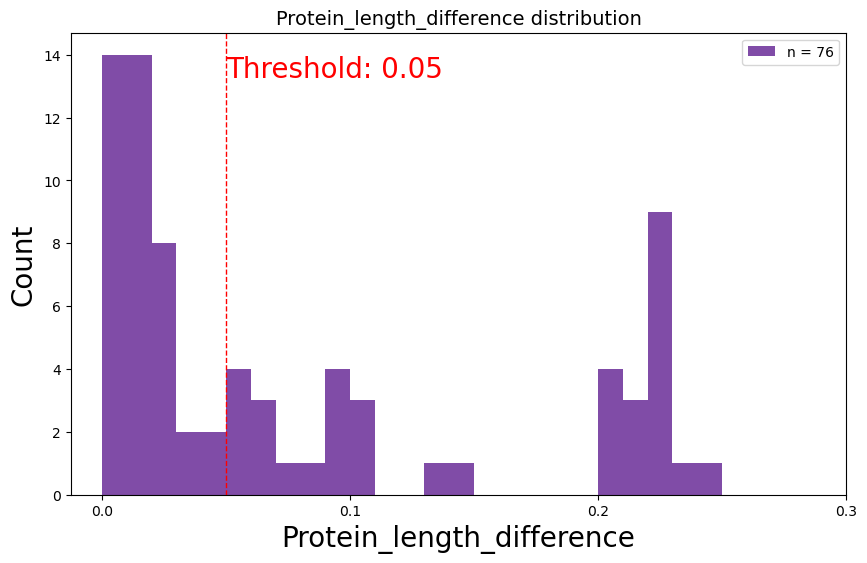

In [37]:
# ────────────────────────────────────────────────────────────
#      Plot hist: length difference
# ────────────────────────────────────────────────────────────

# PLot histogram of `Protein_length_difference`
def out_plot(
        figure: plt.Figure,
        out_path: str,
        svg: bool = True,
        png_dpi: int = 1080
) -> None:
    out_path = Path(out_path)
    if svg:
        figure.savefig(out_path.with_suffix(".svg"))
    if png_dpi:
        figure.savefig(out_path.with_suffix(".png"), dpi=png_dpi)
    return None

def plot_hist(
        df: pl.DataFrame,
        col_name: str,
        colour: str = "blue",
        alpha: float = 0.7,
        bin_width: float = 10.0,
        tick_interval: float = 0.1,
        exclude_zeros: bool = False,
        last_bin_leftSide: float = None,
        title: str = "Var distribution",
        title_fontSize: int = 14,
        axis_label_fontSize: int = 10,
        xlabel: str = "Var",
        ylabel: str = "Count",
        threshold: float = None,
        threshold_ann: str = None,
        threshold_ann_side: str = "left",
        dims: Tuple[int, int] = (10, 6),
        out_path: str = None
) -> None:

    var = df[col_name].to_numpy().astype(float)
    min, max = var.min(), var.max()
    logger.info(f"{col_name} max: {round(max, 4):,}")
    logger.info(f"{col_name} min: {round(min, 4):,}")
    fig, ax = plt.subplots(figsize=dims)

    if exclude_zeros:
        var = var[var != 0]
        min = var.min()
        logger.info(f"Trimmed min {col_name}: {min}")
        
    if last_bin_leftSide is not None:
        var = np.where(
            var > last_bin_leftSide,
            last_bin_leftSide + bin_width,
            var
        )
        max = var.max()
        def _fmt(x, pos):
            if np.isclose(x, max - bin_width):
                return f"{int(last_bin_leftSide):,}+"
            return f"{int(x):,}"
        
        logger.info(f"Trimmed max {col_name}: {max}")
    
    else:
        def _fmt(x, pos):
            return f"{round(x, 2):,}"

    l = np.floor(min / tick_interval) * tick_interval
    u = np.ceil(max / tick_interval) * tick_interval
    xticks = np.arange(l, u, tick_interval)

    l = np.floor(min / bin_width) * bin_width
    u = np.ceil(max / bin_width) * bin_width
    edges = np.arange(l, u + bin_width, bin_width)

    ax.hist(var, bins=edges, color=colour, alpha=alpha, label=f"n = {var.size:,}")
    ax.legend()
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.xaxis.set_major_formatter(FuncFormatter(_fmt))
    ax.set_xticks(xticks)
    ax.set_xlabel(xlabel, fontsize=axis_label_fontSize)
    ax.set_ylabel(ylabel, fontsize=axis_label_fontSize)
    ax.set_title(title, fontsize=title_fontSize)

    if threshold is not None:
        ax.axvline(x=threshold, color="red", linestyle="--", linewidth=1)
        if threshold_ann is None:
            threshold_ann = f"Threshold: {threshold}"
        ax.text(threshold, ax.get_ylim()[1]*0.95, threshold_ann, color="red", ha=threshold_ann_side, va="top", fontsize=axis_label_fontSize)

    if out_path is not None:
        out_plot(figure=fig, out_path=out_path, svg=True, png_dpi=1080)

    plt.show()

plot_hist(
    df=df_ann,
    colour="indigo",
    col_name=VAR_NAME_LENGTH_ERROR,
    tick_interval=0.1,
    bin_width=0.01,
    title=f"{VAR_NAME_LENGTH_ERROR} distribution",
    xlabel=VAR_NAME_LENGTH_ERROR,
    out_path=f"{OUT_DIR}/hist_{VAR_NAME_LENGTH_ERROR}",
    threshold=THRESHOLD_LENGTH_ERROR,
    axis_label_fontSize=20
)

In [ ]:
# ────────────────────────────────────────────────────────────
#      Plot hist: Overlap ratio
# ────────────────────────────────────────────────────────────

plot_hist(
    df=df_ann,
    col_name="Overlap_ratio",
    colour="green",
    tick_interval=0.1,
    bin_width=0.01,
    title=f"Overlap_ratio distribution",
    xlabel="Overlap_ratio",
    axis_label_fontSize=20,
    out_path=f"{OUT_DIR}/hist_Overlap_ratio",
    threshold=THRESHOLD_OVERLAP_RATIO,
    threshold_ann_side="right"
)

In [33]:
df_ann.schema[VAR_NAME_LENGTH_ERROR]

Float64

In [32]:
type(VAR_NAME_LENGTH_ERROR)

str